In [ ]:


import os
import glob
import json
import re
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def step_from_path(path: str) -> int:
    m = re.search(r"checkpoint-(\d+)", path)
    return int(m.group(1)) if m else -1


def _coerce_numeric(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def dedupe_by_step(df: pd.DataFrame, required_cols: List[str]) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    out = _coerce_numeric(
        df,
        ["step", "epoch", "loss", "learning_rate", "eval_loss", "eval_iou", "eval_dice"]
    )

    keep_cols = [c for c in required_cols if c in out.columns]
    if "step" not in out.columns:
        return pd.DataFrame(columns=out.columns)

    out = out.dropna(subset=["step"] + keep_cols)
    out = out.sort_values("step").drop_duplicates(subset=["step"], keep="last").reset_index(drop=True)
    return out


def collect_run_logs(run_dir: str) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    trainer_states = sorted(
        glob.glob(os.path.join(run_dir, "checkpoint-*", "trainer_state.json")),
        key=step_from_path
    )

    train_rows, eval_rows = [], []

    for tsp in trainer_states:
        ckpt_step = step_from_path(tsp)
        try:
            with open(tsp, "r") as f:
                st = json.load(f)
        except Exception as e:
            print(f"[WARN] Could not read {tsp}: {e}")
            continue

        for h in st.get("log_history", []):
            if "step" not in h:
                continue

            row = dict(h)
            row["_ckpt_step_folder"] = ckpt_step
            row["_trainer_state_path"] = tsp

            # train log row
            if ("loss" in h) and ("eval_loss" not in h):
                train_rows.append(row)

            # eval log row
            if "eval_loss" in h:
                eval_rows.append(row)

    train_df = pd.DataFrame(train_rows)
    eval_df = pd.DataFrame(eval_rows)

    train_df = dedupe_by_step(train_df, required_cols=["loss"])
    eval_df = dedupe_by_step(eval_df, required_cols=["eval_loss"])

    return train_df, eval_df, trainer_states


def pick_best_row(
    eval_df: pd.DataFrame,
    preferred_metric: str = "eval_iou"
) -> Tuple[Optional[pd.Series], Optional[str], Optional[str]]:
    """
    Returns (best_row, metric_used, mode).
    mode is 'max' or 'min'.
    Fallback order if preferred missing: eval_iou -> eval_dice -> eval_loss
    """
    if eval_df.empty:
        return None, None, None

    candidates = [preferred_metric] + [c for c in ["eval_iou", "eval_dice", "eval_loss"] if c != preferred_metric]

    for col in candidates:
        if col in eval_df.columns and eval_df[col].notna().any():
            mode = "min" if col == "eval_loss" else "max"
            idx = eval_df[col].idxmin() if mode == "min" else eval_df[col].idxmax()
            return eval_df.loc[idx], col, mode

    return None, None, None


def resolve_checkpoint(run_dir: str, best_step: int, trainer_states: List[str]) -> Tuple[Optional[int], Optional[str]]:
    """
    Resolve best_step to an existing checkpoint folder.
    - exact if present
    - else nearest lower/equal checkpoint
    - else nearest absolute checkpoint
    """
    ckpt_steps = sorted({step_from_path(p) for p in trainer_states if step_from_path(p) >= 0})
    if not ckpt_steps:
        return None, None

    if best_step in ckpt_steps:
        chosen = best_step
    else:
        lower_or_equal = [s for s in ckpt_steps if s <= best_step]
        if lower_or_equal:
            chosen = max(lower_or_equal)
        else:
            chosen = min(ckpt_steps, key=lambda s: abs(s - best_step))

    ckpt_path = os.path.join(run_dir, f"checkpoint-{chosen}")
    return chosen, ckpt_path


def plot_run_diagnostics(
    run_name: str,
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    best_step: Optional[int] = None,
    smooth_window: int = 8,
    show: bool = True,
    save_dir: Optional[str] = None,
) -> None:
    """
    Produces the same style of plots as your notebook:
    1) raw train loss
    2) smoothed train loss
    3) train(smoothed) vs eval_loss
    4) eval_iou + eval_dice vs step
    5) eval_iou with best step marked
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    # 1) raw train loss
    if not train_df.empty and "loss" in train_df.columns:
        fig = plt.figure(figsize=(10, 5))
        plt.plot(train_df["step"], train_df["loss"])
        plt.xlabel("Step")
        plt.ylabel("Train loss")
        plt.title(f"[{run_name}] Training Loss vs Step (raw)")
        plt.grid(True)
        if save_dir:
            fig.savefig(os.path.join(save_dir, "01_train_loss_raw.png"), bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close(fig)

    # 2) smoothed train loss
    train_plot_df = train_df.copy()
    if not train_plot_df.empty and "loss" in train_plot_df.columns:
        train_plot_df["loss_smooth"] = train_plot_df["loss"].rolling(smooth_window, min_periods=1).mean()

        fig = plt.figure(figsize=(10, 5))
        plt.plot(train_plot_df["step"], train_plot_df["loss_smooth"])
        plt.xlabel("Step")
        plt.ylabel("Train loss (smoothed)")
        plt.title(f"[{run_name}] Training Loss vs Step (rolling mean, window={smooth_window})")
        plt.grid(True)
        if save_dir:
            fig.savefig(os.path.join(save_dir, "02_train_loss_smooth.png"), bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close(fig)

        # 3) train vs eval loss
        if not eval_df.empty and "eval_loss" in eval_df.columns:
            fig = plt.figure(figsize=(10, 5))
            plt.plot(train_plot_df["step"], train_plot_df["loss_smooth"], label="train loss (smoothed)")
            plt.plot(eval_df["step"], eval_df["eval_loss"], marker="o", label="eval_loss")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title(f"[{run_name}] Train vs Eval Loss")
            plt.grid(True)
            plt.legend()
            if save_dir:
                fig.savefig(os.path.join(save_dir, "03_train_vs_eval_loss.png"), bbox_inches="tight")
            if show:
                plt.show()
            else:
                plt.close(fig)

    # 4) eval metrics vs step
    if not eval_df.empty:
        has_iou = "eval_iou" in eval_df.columns and eval_df["eval_iou"].notna().any()
        has_dice = "eval_dice" in eval_df.columns and eval_df["eval_dice"].notna().any()

        if has_iou or has_dice:
            fig = plt.figure(figsize=(10, 5))
            if has_iou:
                plt.plot(eval_df["step"], eval_df["eval_iou"], marker="o", label="eval_iou")
            if has_dice:
                plt.plot(eval_df["step"], eval_df["eval_dice"], marker="o", label="eval_dice")
            plt.xlabel("Step")
            plt.ylabel("Metric")
            plt.title(f"[{run_name}] Eval Metrics vs Step")
            plt.grid(True)
            plt.legend()
            if save_dir:
                fig.savefig(os.path.join(save_dir, "04_eval_metrics_vs_step.png"), bbox_inches="tight")
            if show:
                plt.show()
            else:
                plt.close(fig)

    # 5) eval_iou with best step marked
    if (
        not eval_df.empty
        and "eval_iou" in eval_df.columns
        and eval_df["eval_iou"].notna().any()
    ):
        fig = plt.figure(figsize=(10, 5))
        plt.plot(eval_df["step"], eval_df["eval_iou"], marker="o", label="eval_iou")

        if best_step is not None:
            match = eval_df.loc[eval_df["step"] == best_step]
            if len(match) == 1:
                best_iou = float(match["eval_iou"].iloc[0])
                plt.axvline(best_step, linestyle="--", label=f"best step = {best_step}")
                plt.scatter([best_step], [best_iou], s=80)

        plt.xlabel("Step")
        plt.ylabel("eval_iou")
        plt.title(f"[{run_name}] Eval IoU vs Step (Best Checkpoint Marked)")
        plt.grid(True)
        plt.legend()
        if save_dir:
            fig.savefig(os.path.join(save_dir, "05_eval_iou_best_marked.png"), bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close(fig)


def analyze_all_runs(
    run_root: str,
    preferred_metric: str = "eval_iou",
    smooth_window: int = 8,
    expected_subfolders: Optional[int] = 4,
    save_root: Optional[str] = "./fft_outputs",
    show_plots: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, pd.DataFrame]]]:
    """
    Main driver: executes analysis once per subfolder in run_root.
    If there are 4 subfolders, it runs 4 times automatically.
    """
    if not os.path.isdir(run_root):
        raise FileNotFoundError(f"RUN_DIR not found: {run_root}")

    run_dirs = sorted([p for p in glob.glob(os.path.join(run_root, "*")) if os.path.isdir(p)])

    print(f"Found {len(run_dirs)} subfolders under {run_root}:")
    for rd in run_dirs:
        print(" -", os.path.basename(rd))

    if expected_subfolders is not None and len(run_dirs) != expected_subfolders:
        print(f"[WARN] Expected {expected_subfolders} subfolders, found {len(run_dirs)}")

    summary_rows = []
    run_data: Dict[str, Dict[str, pd.DataFrame]] = {}

    for run_dir in run_dirs:
        run_name = os.path.basename(run_dir.rstrip("/"))
        print("\n" + "=" * 100)
        print(f"[RUN] {run_name}")

        train_df, eval_df, trainer_states = collect_run_logs(run_dir)
        print(f"trainer_state files: {len(trainer_states)}")
        print(f"unique train steps: {len(train_df)}")
        print(f"unique eval steps : {len(eval_df)}")

        best_row, metric_used, mode = pick_best_row(eval_df, preferred_metric=preferred_metric)

        if best_row is None:
            print("[WARN] No usable eval metric found.")
            summary_rows.append({
                "run_name": run_name,
                "metric_used": None,
                "mode": None,
                "best_score": np.nan,
                "best_step": np.nan,
                "best_epoch": np.nan,
                "best_eval_iou": np.nan,
                "best_eval_dice": np.nan,
                "best_eval_loss": np.nan,
                "resolved_ckpt_step": np.nan,
                "resolved_checkpoint_path": None,
                "n_trainer_states": len(trainer_states),
                "n_train_steps": len(train_df),
                "n_eval_steps": len(eval_df),
            })
            run_data[run_name] = {"train_df": train_df, "eval_df": eval_df}
            continue

        best_step = int(best_row["step"])
        resolved_step, resolved_ckpt_path = resolve_checkpoint(run_dir, best_step, trainer_states)
        best_score = float(best_row[metric_used]) if pd.notna(best_row[metric_used]) else np.nan

        print(f"metric used: {metric_used} ({mode})")
        print(f"best step : {best_step}")
        if "epoch" in best_row and pd.notna(best_row["epoch"]):
            print(f"best epoch: {float(best_row['epoch'])}")
        if "eval_iou" in best_row and pd.notna(best_row["eval_iou"]):
            print(f"eval_iou : {float(best_row['eval_iou']):.6f}")
        if "eval_dice" in best_row and pd.notna(best_row["eval_dice"]):
            print(f"eval_dice: {float(best_row['eval_dice']):.6f}")
        if "eval_loss" in best_row and pd.notna(best_row["eval_loss"]):
            print(f"eval_loss: {float(best_row['eval_loss']):.6f}")
        print(f"resolved checkpoint: {resolved_ckpt_path}")

        plot_save_dir = os.path.join(save_root, run_name) if save_root else None
        plot_run_diagnostics(
            run_name=run_name,
            train_df=train_df,
            eval_df=eval_df,
            best_step=best_step,
            smooth_window=smooth_window,
            show=show_plots,
            save_dir=plot_save_dir,
        )

        summary_rows.append({
            "run_name": run_name,
            "metric_used": metric_used,
            "mode": mode,
            "best_score": best_score,
            "best_step": best_step,
            "best_epoch": float(best_row["epoch"]) if ("epoch" in best_row and pd.notna(best_row["epoch"])) else np.nan,
            "best_eval_iou": float(best_row["eval_iou"]) if ("eval_iou" in best_row and pd.notna(best_row["eval_iou"])) else np.nan,
            "best_eval_dice": float(best_row["eval_dice"]) if ("eval_dice" in best_row and pd.notna(best_row["eval_dice"])) else np.nan,
            "best_eval_loss": float(best_row["eval_loss"]) if ("eval_loss" in best_row and pd.notna(best_row["eval_loss"])) else np.nan,
            "resolved_ckpt_step": resolved_step if resolved_step is not None else np.nan,
            "resolved_checkpoint_path": resolved_ckpt_path,
            "n_trainer_states": len(trainer_states),
            "n_train_steps": len(train_df),
            "n_eval_steps": len(eval_df),
        })

        run_data[run_name] = {"train_df": train_df, "eval_df": eval_df}

    summary_df = pd.DataFrame(summary_rows)

    if len(summary_df):
        # sort according to preferred metric mode
        preferred_mode = "min" if preferred_metric == "eval_loss" else "max"
        summary_df = summary_df.sort_values(
            "best_score",
            ascending=(preferred_mode == "min"),
            na_position="last"
        ).reset_index(drop=True)

    print("\n" + "=" * 100)
    print("GLOBAL SUMMARY")
    if len(summary_df):
        display_cols = [
            "run_name", "metric_used", "best_score", "best_step", "best_epoch",
            "best_eval_iou", "best_eval_dice", "best_eval_loss",
            "resolved_ckpt_step", "resolved_checkpoint_path"
        ]
        display_cols = [c for c in display_cols if c in summary_df.columns]
        print(summary_df[display_cols].to_string(index=False))
    else:
        print("(No runs summarized)")

    return summary_df, run_data


Found 4 subfolders under ../fine_tune/full_finetuning:
 - lr1e-4
 - lr1e-5
 - lr2e-5
 - lr5e-5

[RUN] lr1e-4
trainer_state files: 3
unique train steps: 849
unique eval steps : 20
metric used: eval_iou (max)
best step : 40337
best epoch: 19.0
eval_iou : 0.594010
eval_dice: 0.506327
eval_loss: 0.306873
resolved checkpoint: ../fine_tune/full_finetuning/lr1e-4/checkpoint-40337


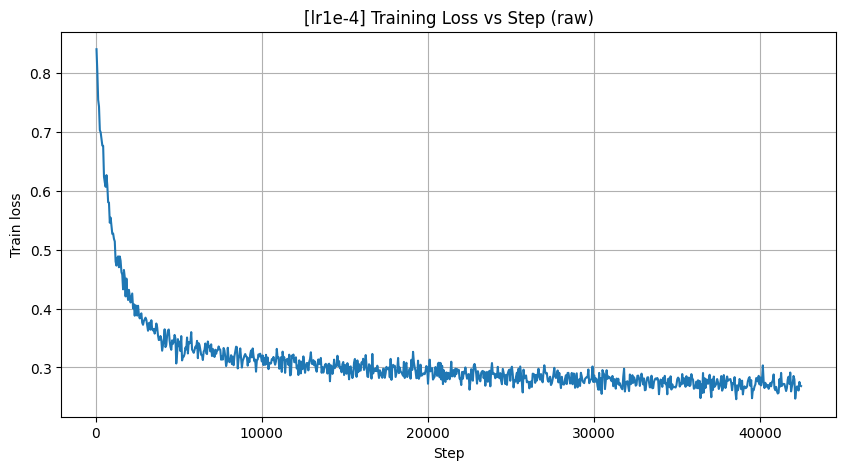

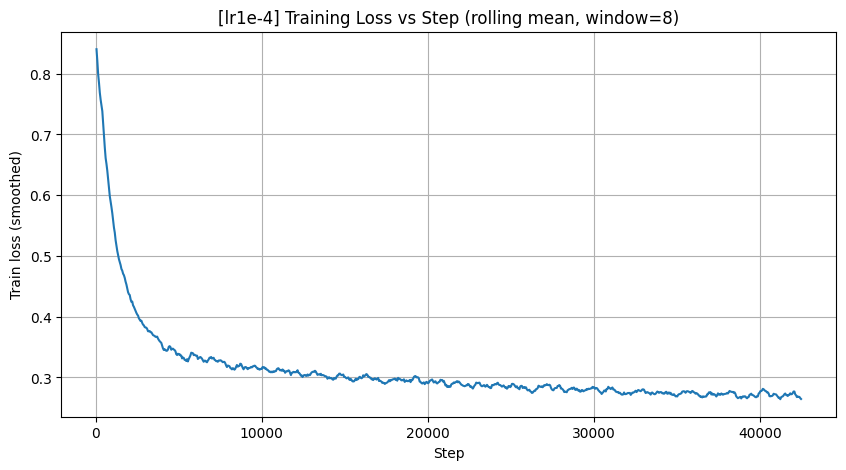

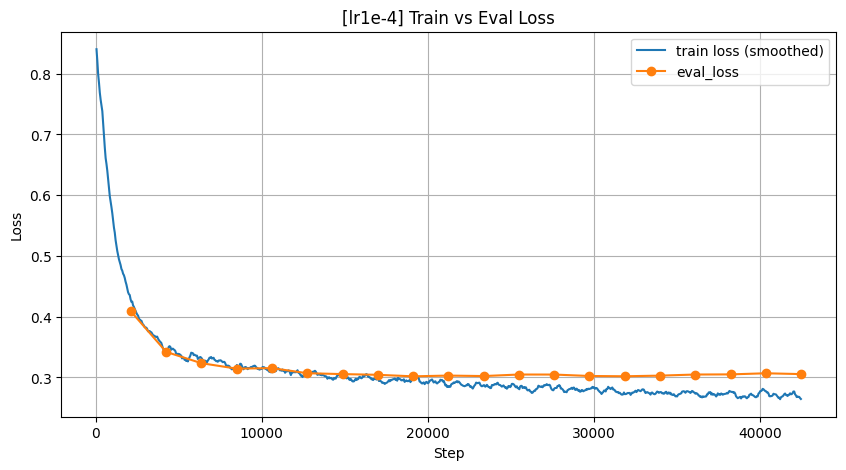

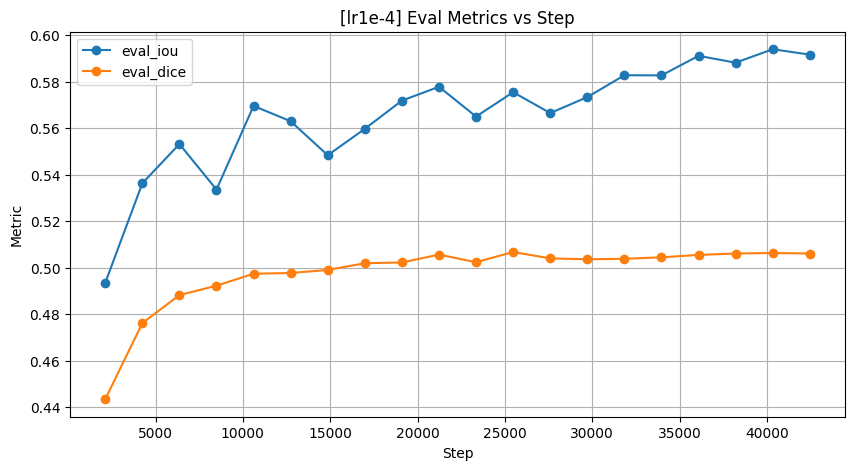

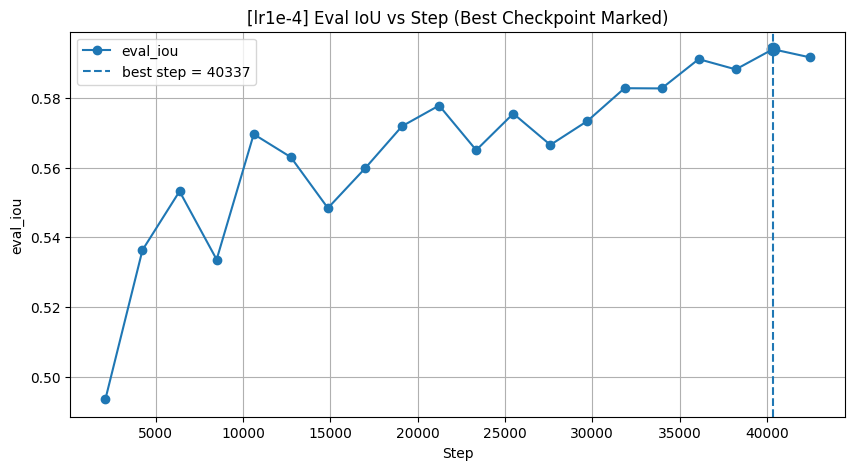


[RUN] lr1e-5
trainer_state files: 3
unique train steps: 849
unique eval steps : 20
metric used: eval_iou (max)
best step : 38214
best epoch: 18.0
eval_iou : 0.523099
eval_dice: 0.472685
eval_loss: 0.355833
resolved checkpoint: ../fine_tune/full_finetuning/lr1e-5/checkpoint-38214


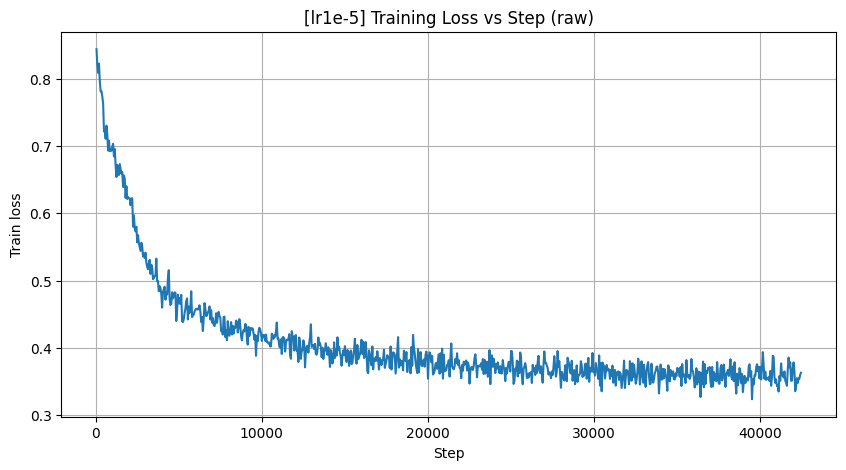

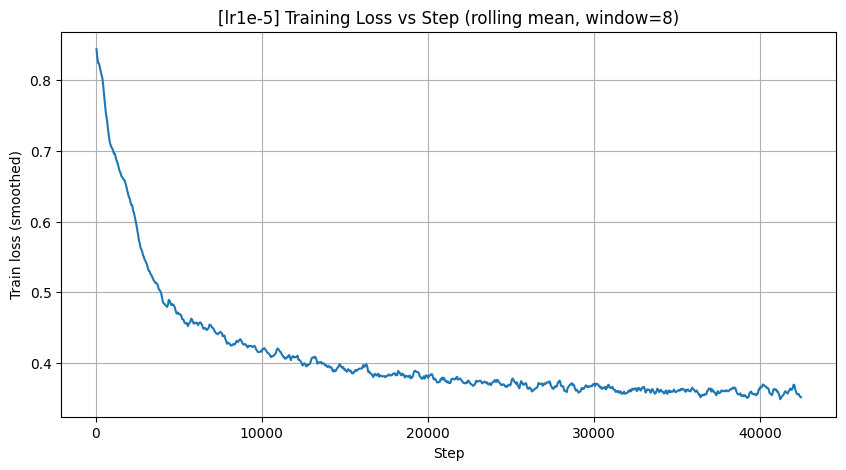

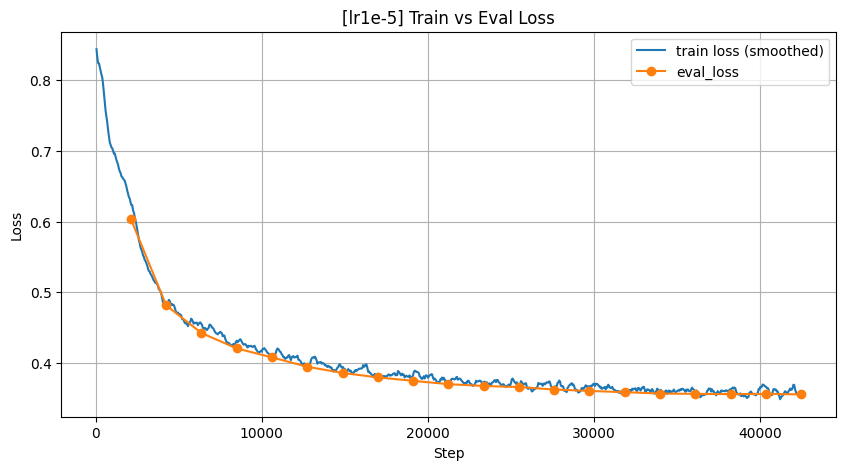

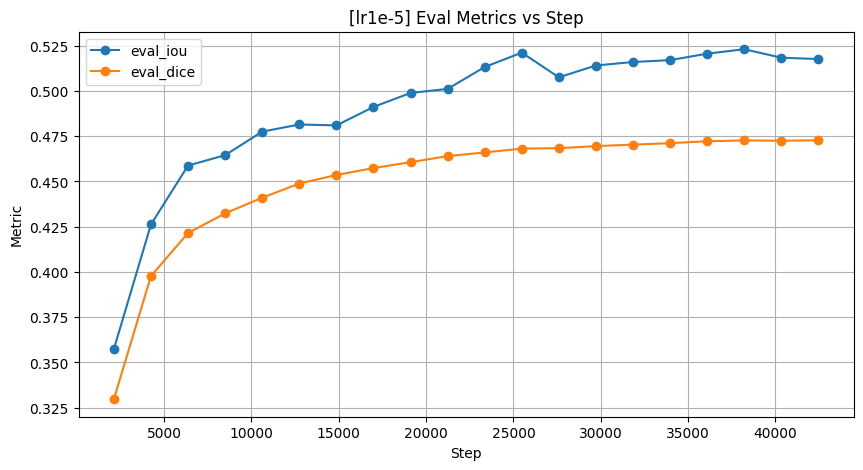

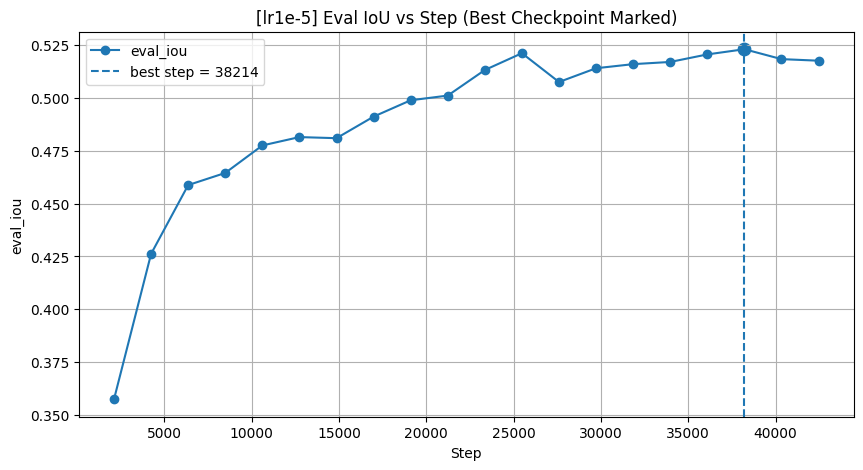


[RUN] lr2e-5
trainer_state files: 3
unique train steps: 849
unique eval steps : 20
metric used: eval_iou (max)
best step : 36091
best epoch: 17.0
eval_iou : 0.546430
eval_dice: 0.487540
eval_loss: 0.329136
resolved checkpoint: ../fine_tune/full_finetuning/lr2e-5/checkpoint-36091


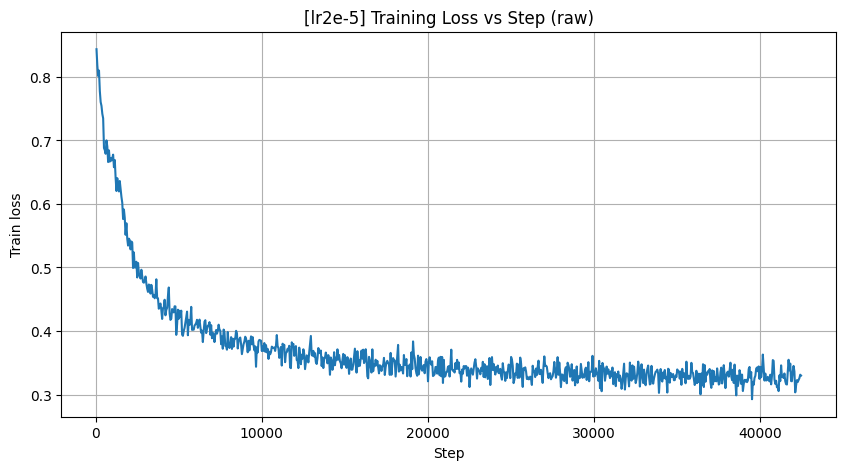

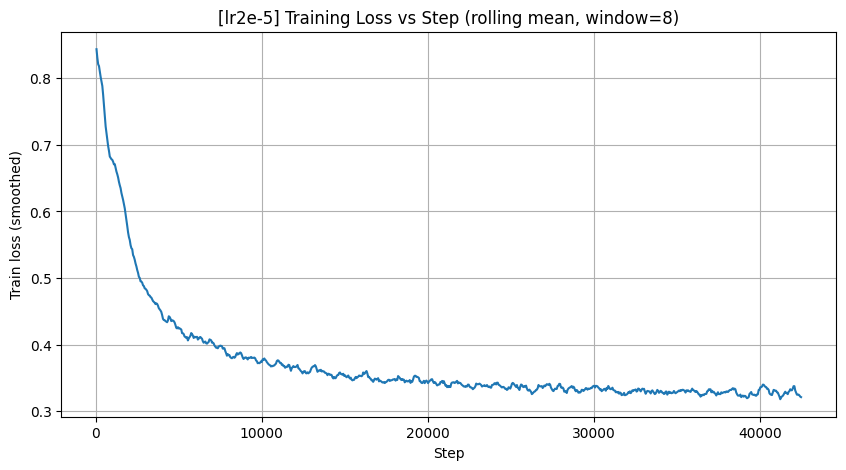

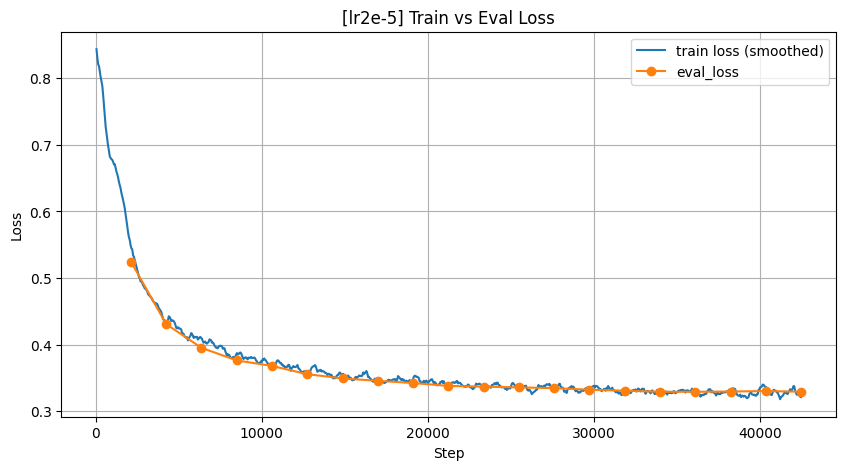

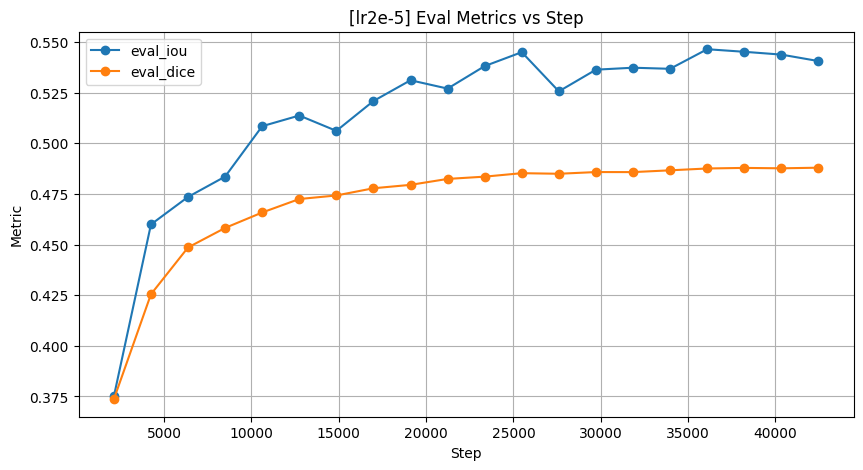

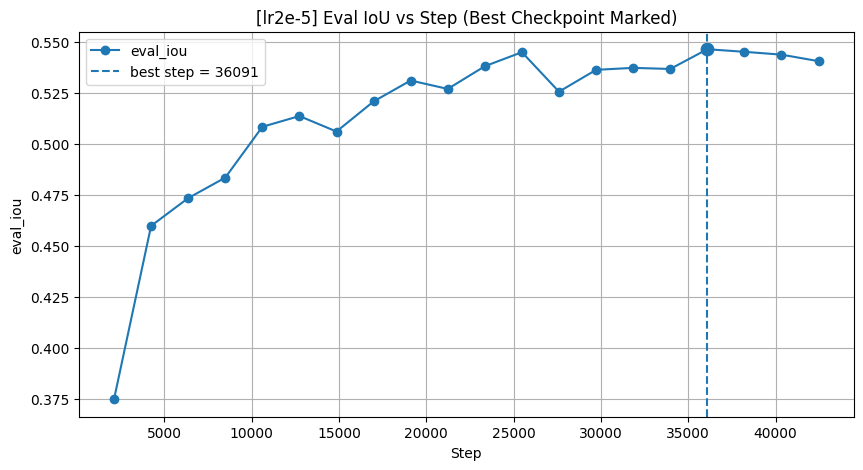


[RUN] lr5e-5
trainer_state files: 3
unique train steps: 849
unique eval steps : 20
metric used: eval_iou (max)
best step : 36091
best epoch: 17.0
eval_iou : 0.572738
eval_dice: 0.499975
eval_loss: 0.308136
resolved checkpoint: ../fine_tune/full_finetuning/lr5e-5/checkpoint-36091


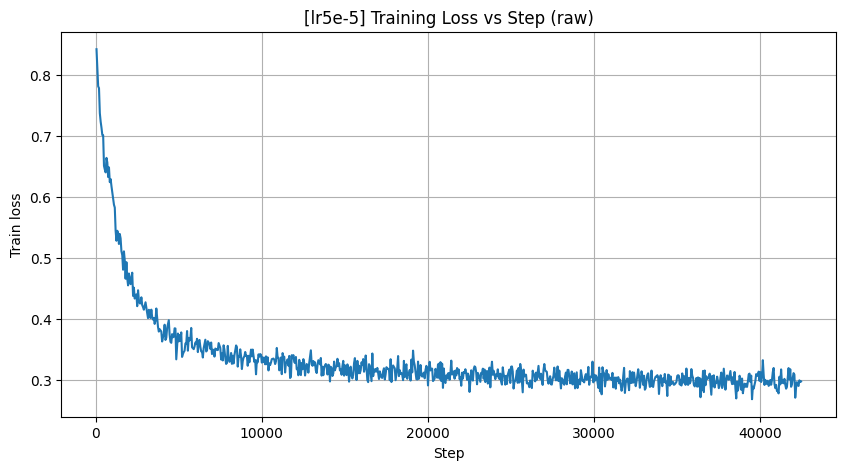

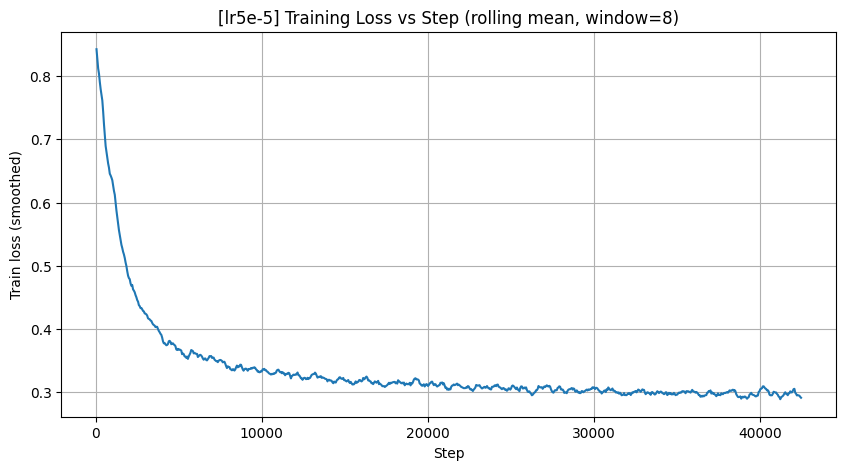

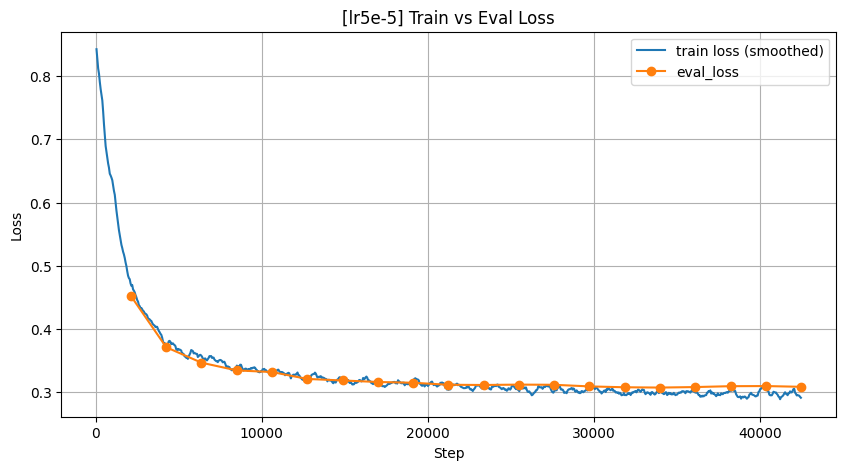

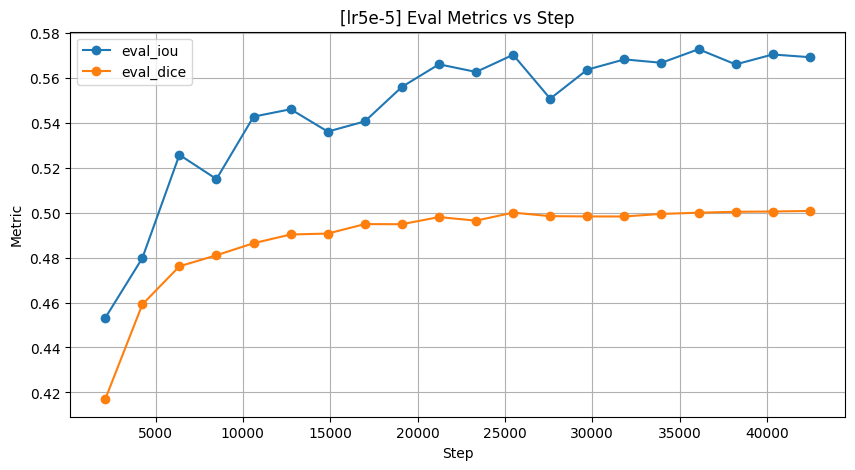

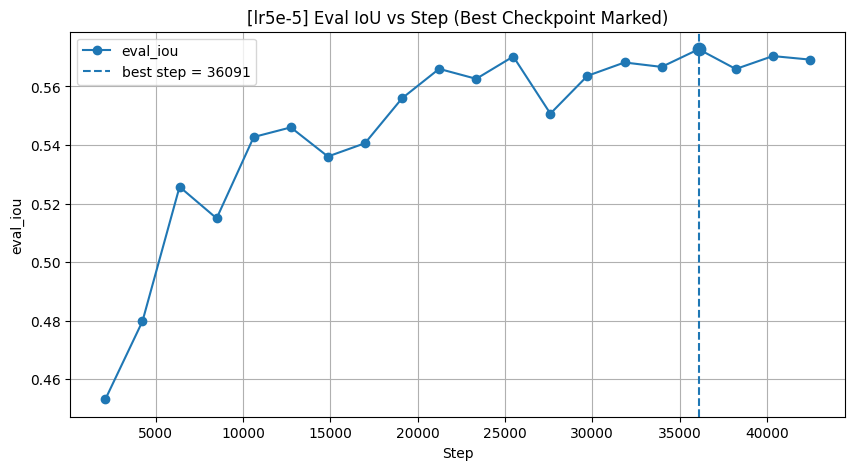


GLOBAL SUMMARY
run_name metric_used  best_score  best_step  best_epoch  best_eval_iou  best_eval_dice  best_eval_loss  resolved_ckpt_step                             resolved_checkpoint_path
  lr1e-4    eval_iou    0.594010      40337        19.0       0.594010        0.506327        0.306873               40337 ../fine_tune/full_finetuning/lr1e-4/checkpoint-40337
  lr5e-5    eval_iou    0.572738      36091        17.0       0.572738        0.499975        0.308136               36091 ../fine_tune/full_finetuning/lr5e-5/checkpoint-36091
  lr2e-5    eval_iou    0.546430      36091        17.0       0.546430        0.487540        0.329136               36091 ../fine_tune/full_finetuning/lr2e-5/checkpoint-36091
  lr1e-5    eval_iou    0.523099      38214        18.0       0.523099        0.472685        0.355833               38214 ../fine_tune/full_finetuning/lr1e-5/checkpoint-38214


,run_name,metric_used,mode,best_score,best_step,best_epoch,best_eval_iou,best_eval_dice,best_eval_loss,resolved_ckpt_step,resolved_checkpoint_path,n_trainer_states,n_train_steps,n_eval_steps
0,lr1e-4,eval_iou,max,0.594010,40337,19.0,0.594010,0.506327,0.306873,40337,../fine_tune/full_finetuning/lr1e-4/checkpoint...,3,849,20
1,lr5e-5,eval_iou,max,0.572738,36091,17.0,0.572738,0.499975,0.308136,36091,../fine_tune/full_finetuning/lr5e-5/checkpoint...,3,849,20
2,lr2e-5,eval_iou,max,0.546430,36091,17.0,0.546430,0.487540,0.329136,36091,../fine_tune/full_finetuning/lr2e-5/checkpoint...,3,849,20
3,lr1e-5,eval_iou,max,0.523099,38214,18.0,0.523099,0.472685,0.355833,38214,../fine_tune/full_finetuning/lr1e-5/checkpoint...,3,849,20


In [2]:
RUN_DIR = "../fine_tune/full_finetuning"   # update if needed

summary_df, run_data = analyze_all_runs(
    run_root=RUN_DIR,
    preferred_metric="eval_iou",  # or "eval_dice" / "eval_loss"
    smooth_window=8,
    expected_subfolders=4,        # warning if not 4
    save_root="./fft_outputs",     # set None if you don't want saved PNGs
    show_plots=True                # True = display plots inline
)

summary_df
